In [9]:
import re
import nltk
# import fasttext
from nltk.corpus import stopwords


import numpy as np
import pandas as pd

from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences

from keras.layers import Conv1D, MaxPooling1D, Embedding, Concatenate, Dense, Input, Flatten
from keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

ModuleNotFoundError: No module named 'keras.preprocessing.text'

In [11]:
import pandas as pd

In [13]:
MAX_SEQUENCE_LENGTH = 100
MAX_NB_WORDS = 2000000
EMBEDDING_DIM = 100

In [15]:
df = pd.read_csv("Amazon_reviews.csv")

In [16]:
df['Score'].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568438 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [6]:
data = df.sample(n=20000)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20000 entries, 418768 to 532439
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      20000 non-null  int64 
 1   ProductId               20000 non-null  object
 2   UserId                  20000 non-null  object
 3   ProfileName             20000 non-null  object
 4   HelpfulnessNumerator    20000 non-null  int64 
 5   HelpfulnessDenominator  20000 non-null  int64 
 6   Score                   20000 non-null  int64 
 7   Time                    20000 non-null  int64 
 8   Summary                 19998 non-null  object
 9   Text                    20000 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.7+ MB


In [19]:
data.reset_index(inplace=True, drop=True)

In [ ]:
wl = nltk.WordNetLemmatizer()
ps = nltk.PorterStemmer()

In [30]:
def preprocess(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z\s]','',text)
    stop = stopwords.words('english')
    text = [ps.stem(wl.lemmatize(word)) for word in text.split() if word not in stop]
    return text
    

In [31]:
processed_data = feature.map(preprocess)

In [38]:
tokenizer = Tokenizer()#num_words = MAX_NB_WORDS)
tokenizer.fit_on_texts(feature)
sequences = tokenizer.texts_to_sequences(feature)

word_index = tokenizer.word_index
len(word_index)

28821

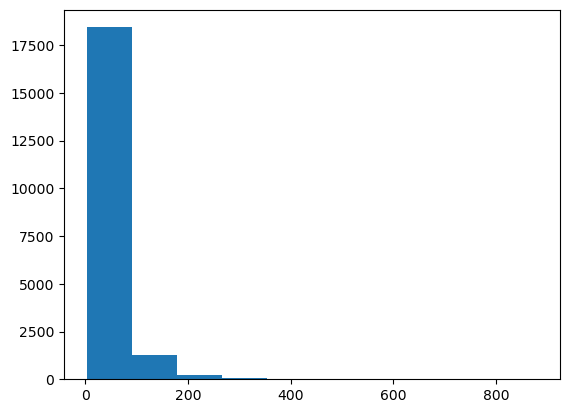

In [44]:
dct = []
for i in sequences:
    dct.append(len(i))
        
plt.hist(dct)
plt.show()

In [46]:
final = pad_sequences(sequences, MAX_SEQUENCE_LENGTH)
labels = pd.get_dummies(label, dtype='int')
final.shape, label.shape

((20000, 100), (20000,))

In [47]:
labels.head()

,1,2,3,4,5
0,1,0,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,0,0,1
4,0,0,0,0,1


In [48]:
x_train, x_test, y_train, y_test = train_test_split(final, labels, test_size = 0.2, random_state = 20)
x_test, x_val, y_test, y_val = train_test_split( final, labels, test_size=0.50, random_state=4)
x_train.shape, x_test.shape, x_val.shape, y_train.shape, y_test.shape, y_val.shape

((16000, 100), (10000, 100), (10000, 100), (16000, 5), (10000, 5), (10000, 5))

In [50]:
# using fasttext
embd = fasttext.load_model(r"D:\Notebook\Projects\Embedding_Models\fasttext_embedding_model.bin")

embedding_matrix = np.random.random((len(word_index) + 1, EMBEDDING_DIM))
for word, i in word_index.items():
    embedding_vector = embd.get_word_vector(word)
    if embedding_vector is not None:
        # words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector
        
embedding_layer = Embedding(len(word_index) + 1,
                            EMBEDDING_DIM,
                            weights=[embedding_matrix],
                            input_length=MAX_SEQUENCE_LENGTH)

In [52]:
convs = []
filter_sizes = [3,4,5]

sequence_input = Input(shape=(MAX_SEQUENCE_LENGTH,))
embedded_sequences = embedding_layer(sequence_input)

for fsz in filter_sizes:
    l_conv = Conv1D(128,fsz,activation='relu')(embedded_sequences)
    l_pool = MaxPooling1D(5)(l_conv)
    convs.append(l_pool)   
l_merge = Concatenate()(convs)
l_cov1= Conv1D(filters=128, kernel_size=5, activation='relu')(l_merge)
l_pool1 = MaxPooling1D(5)(l_cov1)
# l_cov2 = Conv1D(filters=128, kernel_size=5, activation='relu')(l_pool1)
# l_pool2 = MaxPooling1D(30)(l_cov2)
l_flat = Flatten()(l_pool1)
l_dense = Dense(128, activation='relu')(l_flat)
preds = Dense(5, activation='softmax')(l_dense)

model = Model(sequence_input, preds)
model.compile(loss='binary_crossentropy',
              optimizer='Nadam',
              metrics=['acc'])

model.summary()


In [54]:
history = model.fit(x_train, y_train, validation_data=(x_val, y_val),
          epochs=25, batch_size=150)

Epoch 1/20
107/107 [==============================] - 139s 1s/step - loss: 1.0871 - acc: 0.6323 - val_loss: 0.9448 - val_acc: 0.6520
Epoch 2/20
107/107 [==============================] - 132s 1s/step - loss: 0.8818 - acc: 0.6811 - val_loss: 0.7837 - val_acc: 0.7109
Epoch 3/20
107/107 [==============================] - 163s 2s/step - loss: 0.7580 - acc: 0.7210 - val_loss: 0.6955 - val_acc: 0.7479
Epoch 4/20
107/107 [==============================] - 142s 1s/step - loss: 0.6607 - acc: 0.7582 - val_loss: 0.6527 - val_acc: 0.7606
Epoch 5/20
107/107 [==============================] - 135s 1s/step - loss: 0.5740 - acc: 0.7909 - val_loss: 0.5687 - val_acc: 0.8044
Epoch 6/20
107/107 [==============================] - 218s 2s/step - loss: 0.5164 - acc: 0.8129 - val_loss: 0.5291 - val_acc: 0.8259
Epoch 7/20
107/107 [==============================] - 221s 2s/step - loss: 0.4261 - acc: 0.8513 - val_loss: 0.4826 - val_acc: 0.8504
Epoch 8/20
107/107 [==============================] - 231s 2s/step - 

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline 
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [55]:
y_pred = model.predict(x_test, verbose=1)

313/313 [==============================] - 38s 114ms/step


In [62]:
def fx(array):
    return np.argmax(array)

temp = np.array(y_test)
st_pred = y_pred.tolist()
st_temp = temp.tolist()

arr = np.array(list(map(fx,st_temp)))
ans = np.array(list(map(fx,st_pred)))
f1 = f1_score(arr,ans, average='micro')
r1 = recall_score(arr, ans, average='micro')
p1 = precision_score(arr,ans, average='micro')
acc = accuracy_score(arr,ans)
print('f1',f1)
print('r1',r1)
print('p1',p1)
print('acc', acc)

f1 0.9148
r1 0.9148
p1 0.9148
acc 0.9148
